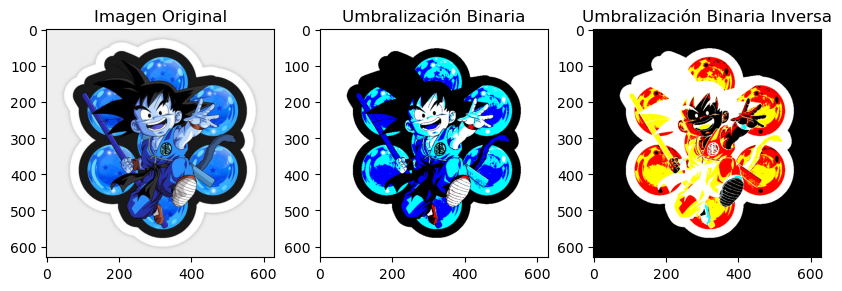

In [4]:
import cv2
import matplotlib.pyplot as plt
imagen = cv2.imread('goku.jpg') # lee en escala de grises
#umbralizacion binaria
_, umbral_binario = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY)
# umbralizacion binaria inversa
_,umbral_binario_inv = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.title('Imagen Original')
plt.imshow(imagen, cmap='gray')

plt.subplot(1, 3, 2)
plt.title('Umbralización Binaria')
plt.imshow(umbral_binario, cmap='gray')

plt.subplot(1, 3, 3)
plt.title('Umbralización Binaria Inversa')
plt.imshow(umbral_binario_inv, cmap='gray')

plt.show()

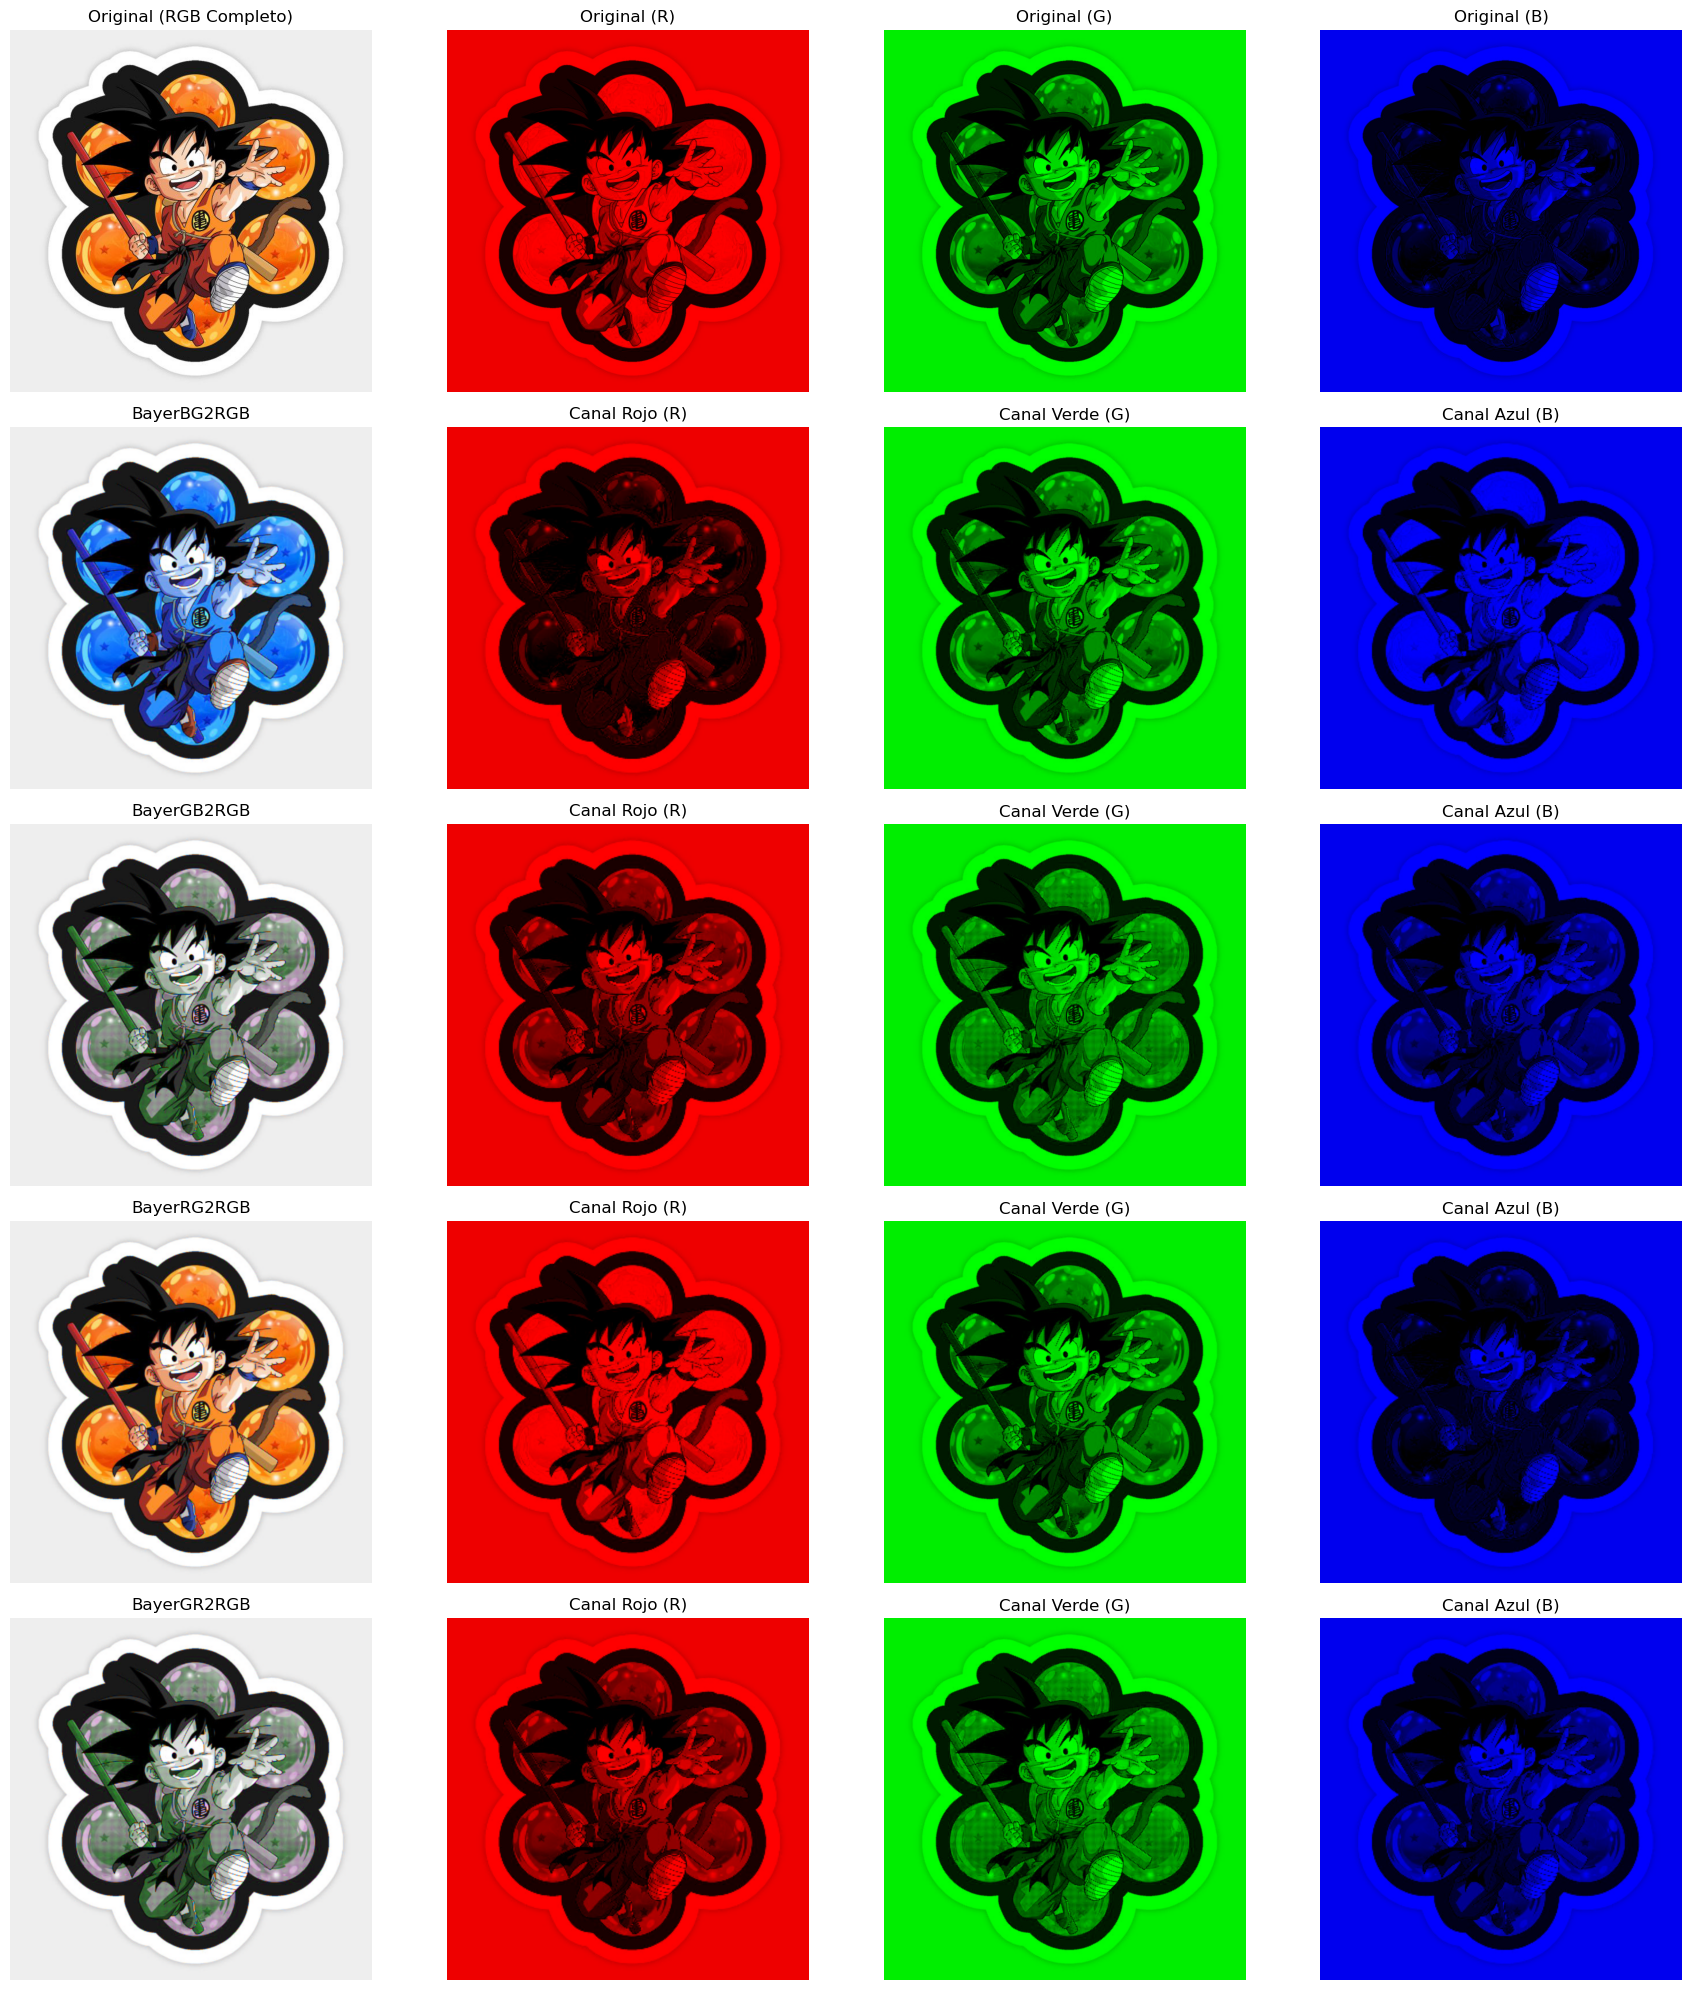

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_bgr = cv2.imread('goku.jpg')
img_rgb_orig = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
canal_r_orig, canal_g_orig, canal_b_orig = cv2.split(img_rgb_orig)

zeros = np.zeros_like(canal_r_orig)
img_r_orig = cv2.merge([canal_r_orig, zeros, zeros])
img_g_orig = cv2.merge([zeros, canal_g_orig, zeros])
img_b_orig = cv2.merge([zeros, zeros, canal_b_orig])

alto, ancho = img_bgr.shape[:2]
mosaico_bayer = np.zeros((alto, ancho), dtype=np.uint8)

mosaico_bayer[0::2, 0::2] = img_bgr[0::2, 0::2, 0] 
mosaico_bayer[0::2, 1::2] = img_bgr[0::2, 1::2, 1] 
mosaico_bayer[1::2, 0::2] = img_bgr[1::2, 0::2, 1] 
mosaico_bayer[1::2, 1::2] = img_bgr[1::2, 1::2, 2] 

versiones = {
    "BayerBG2RGB": cv2.COLOR_BayerBG2RGB,
    "BayerGB2RGB": cv2.COLOR_BayerGB2RGB,
    "BayerRG2RGB": cv2.COLOR_BayerRG2RGB,
    "BayerGR2RGB": cv2.COLOR_BayerGR2RGB
}

fig, axes = plt.subplots(5, 4, figsize=(18, 20))

axes[0, 0].imshow(img_rgb_orig)
axes[0, 0].set_title('Original (RGB Completo)')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_r_orig)
axes[0, 1].set_title('Original (R)')
axes[0, 1].axis('off')

axes[0, 2].imshow(img_g_orig)
axes[0, 2].set_title('Original (G)')
axes[0, 2].axis('off')

axes[0, 3].imshow(img_b_orig)
axes[0, 3].set_title('Original (B)')
axes[0, 3].axis('off')

for i, (nombre, codigo) in enumerate(versiones.items()):
    resultado_rgb = cv2.cvtColor(mosaico_bayer, codigo)
    canal_r, canal_g, canal_b = cv2.split(resultado_rgb)

    # Reconstruimos cada canal como imagen RGB
    img_r = cv2.merge([canal_r, zeros, zeros])
    img_g = cv2.merge([zeros, canal_g, zeros])
    img_b = cv2.merge([zeros, zeros, canal_b])

    fila = i + 1

    axes[fila, 0].imshow(resultado_rgb)
    axes[fila, 0].set_title(f'{nombre}')
    axes[fila, 0].axis('off')

    axes[fila, 1].imshow(img_r)
    axes[fila, 1].set_title('Canal Rojo (R)')
    axes[fila, 1].axis('off')

    axes[fila, 2].imshow(img_g)
    axes[fila, 2].set_title('Canal Verde (G)')
    axes[fila, 2].axis('off')

    axes[fila, 3].imshow(img_b)
    axes[fila, 3].set_title('Canal Azul (B)')
    axes[fila, 3].axis('off')

plt.tight_layout()
plt.show()

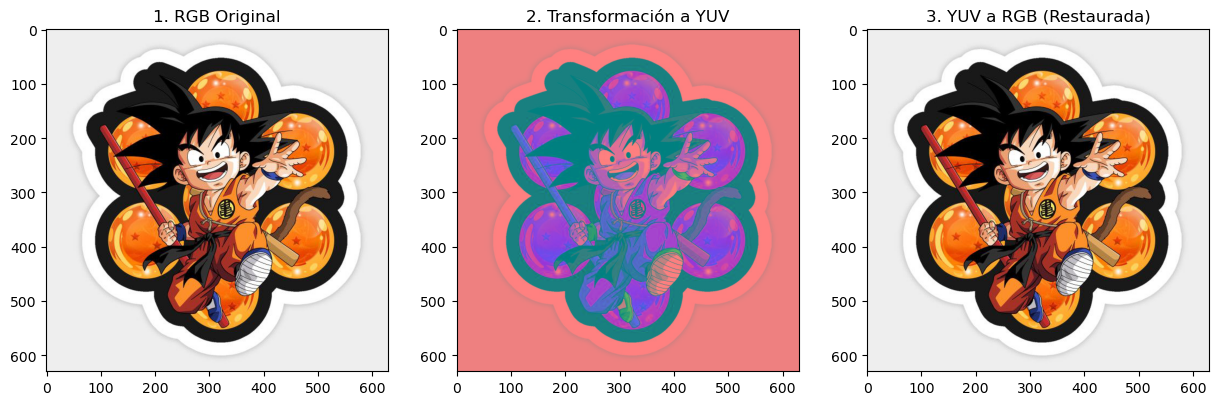

In [7]:
import cv2
import matplotlib.pyplot as plt

imagen_bgr = cv2.imread('goku.jpg')
imagen_rgb_original = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

imagen_yuv = cv2.cvtColor(imagen_rgb_original, cv2.COLOR_RGB2YUV)

imagen_rgb_restaurada = cv2.cvtColor(imagen_yuv, cv2.COLOR_YUV2RGB)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title('1. RGB Original')
plt.imshow(imagen_rgb_original)

plt.subplot(1, 3, 2)
plt.title('2. Transformación a YUV')
plt.imshow(imagen_yuv)

plt.subplot(1, 3, 3)
plt.title('3. YUV a RGB (Restaurada)')
plt.imshow(imagen_rgb_restaurada)

plt.show()

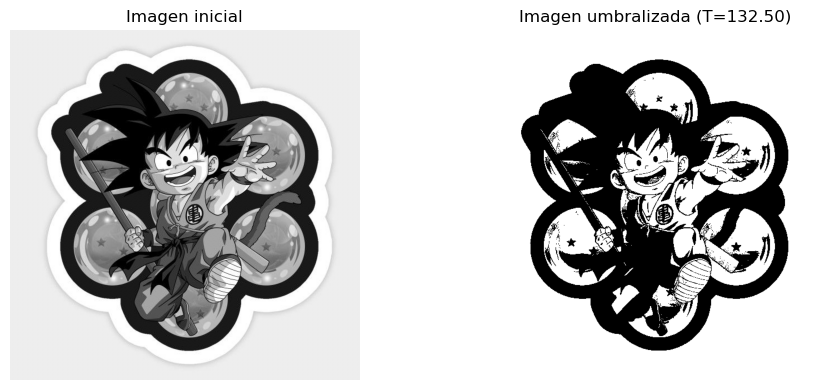

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def isodata(image):
    umbral = 128
    while True:
        grupo1 = image[image <= umbral]  # grupo donde el umbral es menor o igual
        grupo2 = image[image > umbral]   # grupo donde el umbral es mayor

        media1 = np.mean(grupo1) if grupo1.size > 0 else 0
        media2 = np.mean(grupo2) if grupo2.size > 0 else 0

        nuevo_umbral = (media1 + media2) / 2  # nuevo umbral promedio de medias

        if abs(umbral - nuevo_umbral) < 0.5:
            break
        umbral = nuevo_umbral
    return umbral

imagen = cv2.imread('goku.jpg', 0)
if imagen is None:
    raise FileNotFoundError('No hay imagen papito')

umbral_isodata = isodata(imagen)
_, imagen_umbralizada = cv2.threshold(imagen, umbral_isodata, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(imagen, cmap='gray')
plt.title('Imagen inicial')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imagen_umbralizada, cmap='gray')
plt.title(f'Imagen umbralizada (T={umbral_isodata:.2f})')
plt.axis('off')

plt.tight_layout()
plt.show()

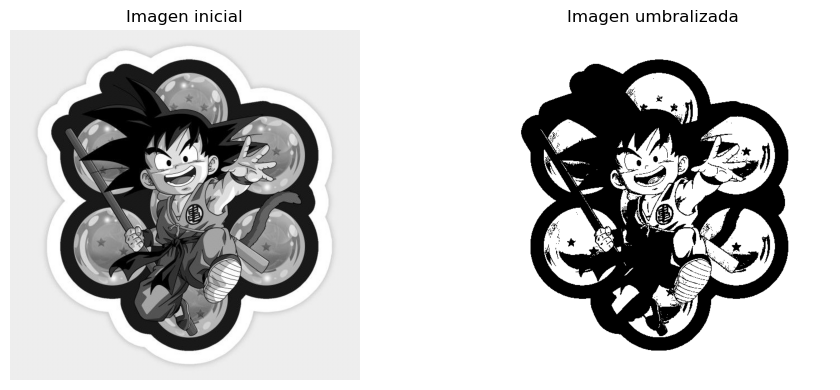

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def dos_picos(image):
    hist = cv2.calcHist([image], [0], None, [256], [0, 256]) #hago uso de histograma
    #seleccionamos los 2 picos 
    pico=np.array(hist)
    pico=pico.flatten()
    pico_dif=np.diff(pico) #diferencia entre los tipos
    primer_pico=np.argmax(pico_dif[:128]) #primer pico
    segundo_pico=np.argmax(pico_dif[128:])+128 #segundo pico

    umbral= int((primer_pico + segundo_pico) / 2) #umbral entre los 2 picos
    return umbral

imagen=cv2.imread('goku.jpg', 0)
umbral_2_picos=dos_picos(imagen)

_, nueva = cv2.threshold(imagen, umbral_2_picos, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(imagen, cmap='gray')
plt.title('Imagen inicial')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(nueva, cmap='gray')
plt.title(f'Imagen umbralizada ')
plt.axis('off')

plt.tight_layout()
plt.show()

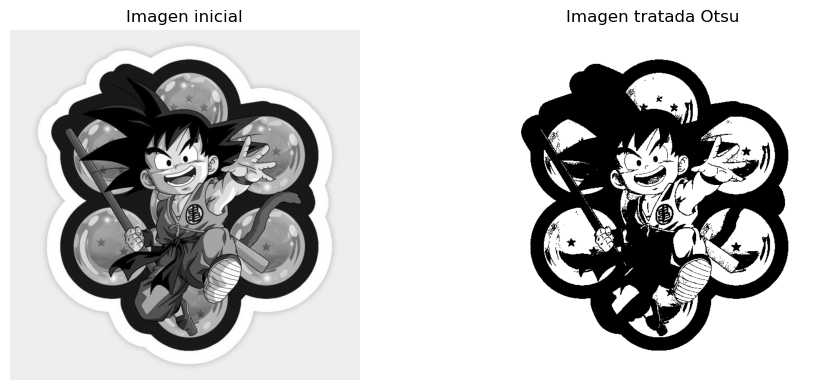

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('goku.jpg', 0)
umbral_otsu, otsu = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
imagen_fin = np.where(image > umbral_otsu, 255, 0).astype(np.uint8)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Imagen inicial')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imagen_fin, cmap='gray')
plt.title(f'Imagen tratada Otsu ')
plt.axis('off')

plt.tight_layout()
plt.show()

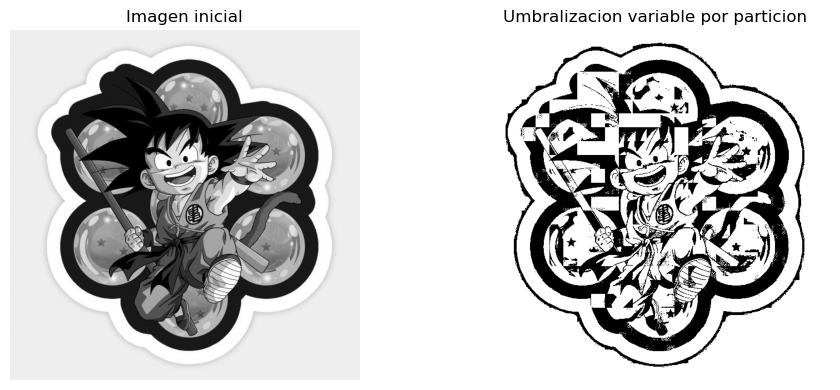

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def variable_part(image, tam_bloque, c):
    umbral_img = np.zeros_like(image)
    for y in range(0, image.shape[0], tam_bloque):
        for x in range(0, image.shape[1], tam_bloque):
            bloque = image[y:y+tam_bloque, x:x+tam_bloque]
            bloq_media = np.mean(bloque)
            umbral = bloq_media - c
            umbral_img[y:y+tam_bloque, x:x+tam_bloque] = (bloque > umbral).astype(np.uint8) * 255
    return umbral_img

tam_b = 25
c = 10
image = cv2.imread('goku.jpg', 0)
img_fin = variable_part(image, tam_b, c)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Imagen inicial')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_fin, cmap='gray')
plt.title('Umbralizacion variable por particion')
plt.axis('off')

plt.tight_layout()
plt.show()

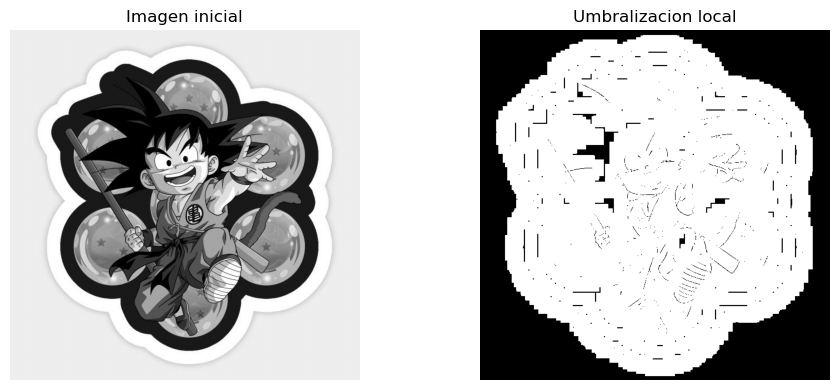

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('goku.jpg', 0)
def local(image, tamanio_ventana, k):
    umbr_img=np.zeros_like(image)
    pad= tamanio_ventana//2
    padded_image = cv2.copyMakeBorder(image, pad, pad, pad, pad, cv2.BORDER_REPLICATE)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            ventana = padded_image[y:y+tamanio_ventana, x:x+tamanio_ventana]
            mean_local=np.mean(ventana)
            std_mean=np.std(ventana)

            umbral=mean_local-(k*std_mean)
            umbr_img[y,x]=255 if image[y,x]>umbral else 0
    return umbr_img
tamanio_ventana=15
k=2
img_fin=local(image, tamanio_ventana, k)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Imagen inicial')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_fin, cmap='gray')
plt.title('Umbralizacion local')
plt.axis('off')

plt.tight_layout()
plt.show()

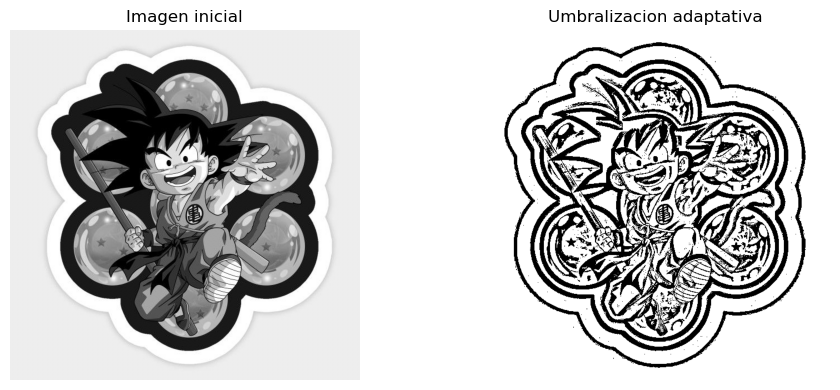

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('goku.jpg', 0)

ventana = 15
k = 2
imagen_fin = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, ventana, k)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Imagen inicial')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imagen_fin, cmap='gray')
plt.title('Umbralizacion adaptativa')
plt.axis('off')

plt.tight_layout()
plt.show()

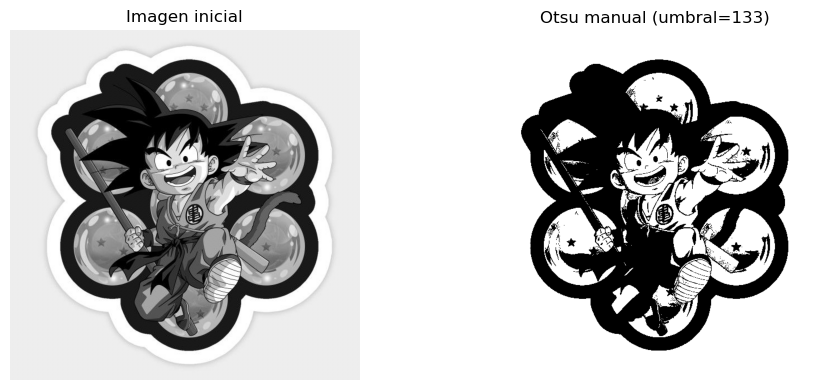

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def otsu_manual(imagen):
    hist, _ = np.histogram(imagen.flatten(), bins=256, range=[0, 256])
    hist = hist.astype(float) / hist.sum()  # probabilidades

    mejor_umbral = 0
    mejor_varianza = 0

    for k in range(1, 256):
        w0 = hist[:k].sum()
        w1 = hist[k:].sum()

        if w0 == 0 or w1 == 0:
            continue

        # Medias
        mu0 = (np.arange(k) * hist[:k]).sum() / w0
        mu1 = (np.arange(k, 256) * hist[k:]).sum() / w1

        varianza_entre_clases = w0 * w1 * (mu0 - mu1) ** 2

        if varianza_entre_clases > mejor_varianza:
            mejor_varianza = varianza_entre_clases
            mejor_umbral = k

    return mejor_umbral

imagen = cv2.imread("goku.jpg", 0)
umbral_otsu = otsu_manual(imagen)

_, img_otsu = cv2.threshold(imagen, umbral_otsu, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(imagen, cmap="gray")
plt.title("Imagen inicial")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_otsu, cmap="gray")
plt.title(f"Otsu manual (umbral={umbral_otsu})")
plt.axis("off")

plt.tight_layout()
plt.show()
